In [1]:
import matplotlib as mpl
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *

In [ ]:
#########################################################################################################
#
#
# Computing the expectation of qubit not being in its intial state
#
#
#########################################################################################################

# max_ql = 25
# max_ol = 20
# system = fluxonium_oscillator_system(
#     EJ = 2.65,
#     EC = 0.6,
#     EL = 0.13,
#     Er = 6.81289062,
#     g_strength = 0.23,
#     qubit_level = max_ql,
#     osc_level = max_ol,
#     products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
#     computaional_states = '0,1',
#     )
# t_stop = 463
# tot_time =500
# tlist = np.linspace(0, tot_time, tot_time)
# with open('pickles/sesolve_detection_results_verify_qubit_transi_01_2-9_g0.23.pkl', 'rb') as file:
#     results = pickle.load(file)
# lists = []
# for ql in [0,1,2]:
#     pop_list = []
#     for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
#         dm = results[ql].states[t_idx]
#         pop_sum = 0
#         for q in range(system.qbt.truncated_dim):
#             if q != ql:
#                 for o in range(system.osc.truncated_dim):
#                     product_state = (q, o)
#                     dressed_state = system.product_to_dressed[product_state]
#                     basis_state = qutip.basis(dm.dims[0][0], dressed_state)
#                     expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
#                     pop_sum += expectation_value
#         pop_list.append(pop_sum)
#     lists.append(pop_list)
# with open('pickles/sesolve_detection_results_verify_qubit_transi_01_2-9_g0.23_list.pkl', 'wb') as file:
#     pickle.dump(lists, file)

# max_ql = 25
# max_ol = 25
# system = fluxonium_oscillator_system(
#     EJ = 3,
#     EC = 0.6,
#     EL = 0.13,
#     Er = 7.26221558,
#     g_strength = 0.3,
#     qubit_level = max_ql,
#     osc_level = max_ol,
#     products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
#     computaional_states = '1,2',
#     )

# t_stop = 477
# tot_time =500
# tlist = np.linspace(0, tot_time, tot_time)

# with open('pickles/sesolve_detection_results_verify_qubit_transi_EJ3_g0.3.pkl', 'rb') as file:
#     results = pickle.load(file)

# lists = []
# for ql in [0,1,2]:
#     pop_list = []
#     for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
#         dm = results[ql].states[t_idx]
#         pop_sum = 0
#         for q in range(system.qbt.truncated_dim):
#             if q != ql:
#                 for o in range(system.osc.truncated_dim):
#                     product_state = (q, o)
#                     dressed_state = system.product_to_dressed[product_state]
#                     basis_state = qutip.basis(dm.dims[0][0], dressed_state)
#                     expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
#                     pop_sum += expectation_value
#         pop_list.append(pop_sum)
#     # print(pop_list)
#     lists.append(pop_list)
# with open('pickles/sesolve_detection_results_verify_qubit_transi_EJ3_g0.3_list.pkl', 'wb') as file:
#     pickle.dump(lists, file)

In [24]:
colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

In [25]:
def plot_population(results,
                    system: fluxonium_oscillator_system,
                    tlist,
                    fourier_which: int = 1,
                    t_cutoff: int = None,
                    legend = False
                    ):
    if t_cutoff == None:
        t_cutoff = len(tlist)-1
    a = system.a
    nlevels = len(results)
    pn_op = jnp.array((a.dag()*a).full())
    vectorized_compute_expectation = vmap(compute_expectation, in_axes=(0, None))
    vectorized_compute_expectation = jit(vectorized_compute_expectation)

    for i in range(nlevels):
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices
        results[i].expect = []
        pns_expect = vectorized_compute_expectation(states, pn_op)
        results[i].expect.append(pns_expect)

    for i in range(nlevels):
        plt.plot(tlist[:t_cutoff], results[i].expect[-1][:t_cutoff], 
                 label=r"$\langle\hat{a}^{\dagger}\hat{a}\rangle$",
                 color = colors[i],
                 linestyle = linestyles[i])
    if legend:
        plt.legend()


 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

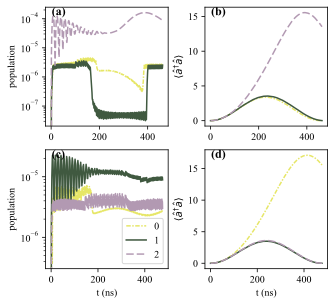

In [33]:
fig = plt.figure(figsize=((3+3/8)*1.5, 
                            (3+3/8)*1.4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1,1], wspace=0.3)



#########################################################################################################
#
# Plotting the first row, about the 0-1 fluxonium
#
#########################################################################################################
max_ql = 25
max_ol = 20
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,1',
    )
t_stop = 463
tot_time =500
tlist = np.linspace(0, tot_time, tot_time)
with open('pickles/sesolve_detection_results_verify_qubit_transi_01_2-9_g0.23.pkl', 'rb') as file:
    results = pickle.load(file)

with open('pickles/sesolve_detection_results_verify_qubit_transi_01_2-9_g0.23_list.pkl', 'rb') as file:
    lists = pickle.load(file)

ax = plt.subplot(gs[0,0])
plt.text(0.05, 1, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for ql,pop_list in enumerate(lists): 
    ax.plot(tlist[:t_stop-1],pop_list[:t_stop-1],label = f"{ql}",
                 color = colors[ql],
                 linestyle = linestyles[ql])
ax.set_yscale('log')
ax.set_ylabel('population')

ax = plt.subplot(gs[0,1])
plt.text(0.05, 1, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plot_population(results,
                    system,
                    tlist,
                    fourier_which = 0,
                    t_cutoff = t_stop)
ax.set_ylabel(r"$\langle\hat{a}^{\dagger}\hat{a}\rangle$")



#########################################################################################################
#
# Plotting the second row, about the 1-2 fluxonium
#
#########################################################################################################
max_ql = 25
max_ol = 25
system = fluxonium_oscillator_system(
    EJ = 3,
    EC = 0.6,
    EL = 0.13,
    Er = 7.26221558,
    g_strength = 0.3,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    )

t_stop = 477
tot_time =500
tlist = np.linspace(0, tot_time, tot_time)

with open('pickles/sesolve_detection_results_verify_qubit_transi_EJ3_g0.3.pkl', 'rb') as file:
    results = pickle.load(file)

with open('pickles/sesolve_detection_results_verify_qubit_transi_EJ3_g0.3_list.pkl', 'rb') as file:
    lists = pickle.load(file)

ax = plt.subplot(gs[1,0])
plt.text(0.05, 1, '(c)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
for ql,pop_list in enumerate(lists): 
    ax.plot(tlist[:t_stop-1],pop_list[:t_stop-1],label = f"{ql}",
                 color = colors[ql],
                 linestyle = linestyles[ql])
ax.set_yscale('log')
ax.legend(loc = 'lower right')
ax.set_xlabel('t (ns)')
ax.set_ylabel('population')

ax = plt.subplot(gs[1,1])
plt.text(0.05, 1, '(d)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plot_population(results,
                    system,
                    tlist,
                    fourier_which = 0,
                    t_cutoff = t_stop,
                    legend=False)
ax.set_xlabel('t (ns)')
ax.set_ylabel(r"$\langle\hat{a}^{\dagger}\hat{a}\rangle$")
plt.savefig('fig04_leakage_and_photon_number.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [2]:
max_ql = 25
max_ol = 20
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,1',
    )
t_stop = 463
tot_time =500
tlist = np.linspace(0, tot_time, tot_time)
with open('pickles/sesolve_detection_results_verify_qubit_transi_01_2-9_g0.23.pkl', 'rb') as file:
    results = pickle.load(file)
    
interactive_heatmap(results[2], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=499), Output(…